In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
#loading data
df=pd.read_csv("../data/data.csv")

In [9]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


1) CRIM : per capita crime rate by town
2) ZN : proportion of residential land zoned for lots over
25,000 sq.ft.
3)  INDUS : proportion of non-retail business acres per town
4) CHAS : Charles River dummy variable (= 1 if tract bounds
river; 0 otherwise)
5) NOX : nitric oxides concentration (parts per 10 million)
6) RM : average number of rooms per dwelling
7) AGE : proportion of owner-occupied units built prior to 1940
8) DIS : weighted distances to five Boston employment centres
9) RAD : index of accessibility to radial highways
10) TAX : full-value property-tax rate per $10,000
11) PTRATIO : pupil-teacher ratio by town
12) B : 1000(Bk - 0.63)^2 where Bk is the proportion of blacks
by town
13) LSTAT : % lower status of the population
14) MEDV : Median value of owner-occupied homes in $1000's

Text(0.5, 0.98, 'Feature Distributions')

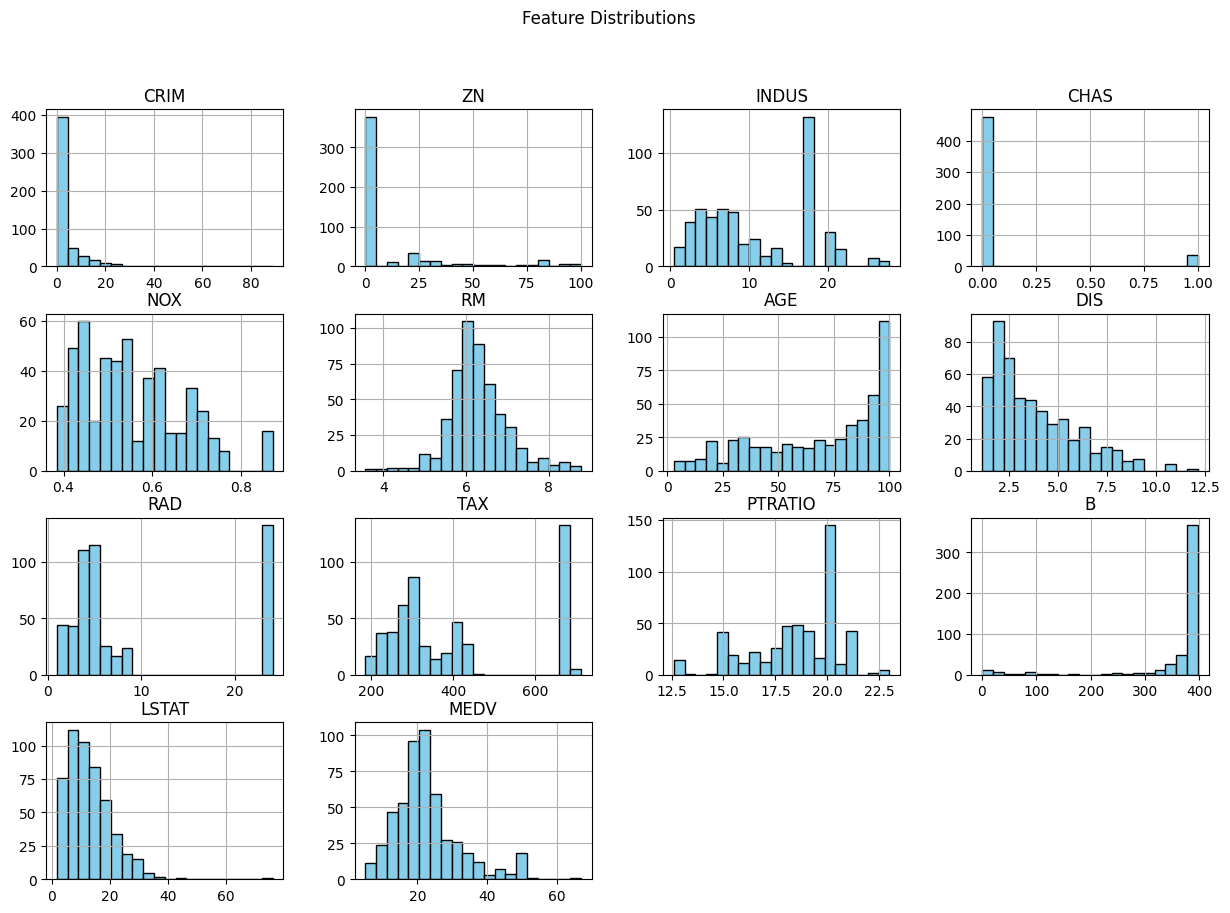

In [ ]:
# 1. Distribution Analysis (Histograms)
# to Checks if features are normal or skewed

df.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions")


Text(0.5, 1.0, 'Outlier Detection across all Features')

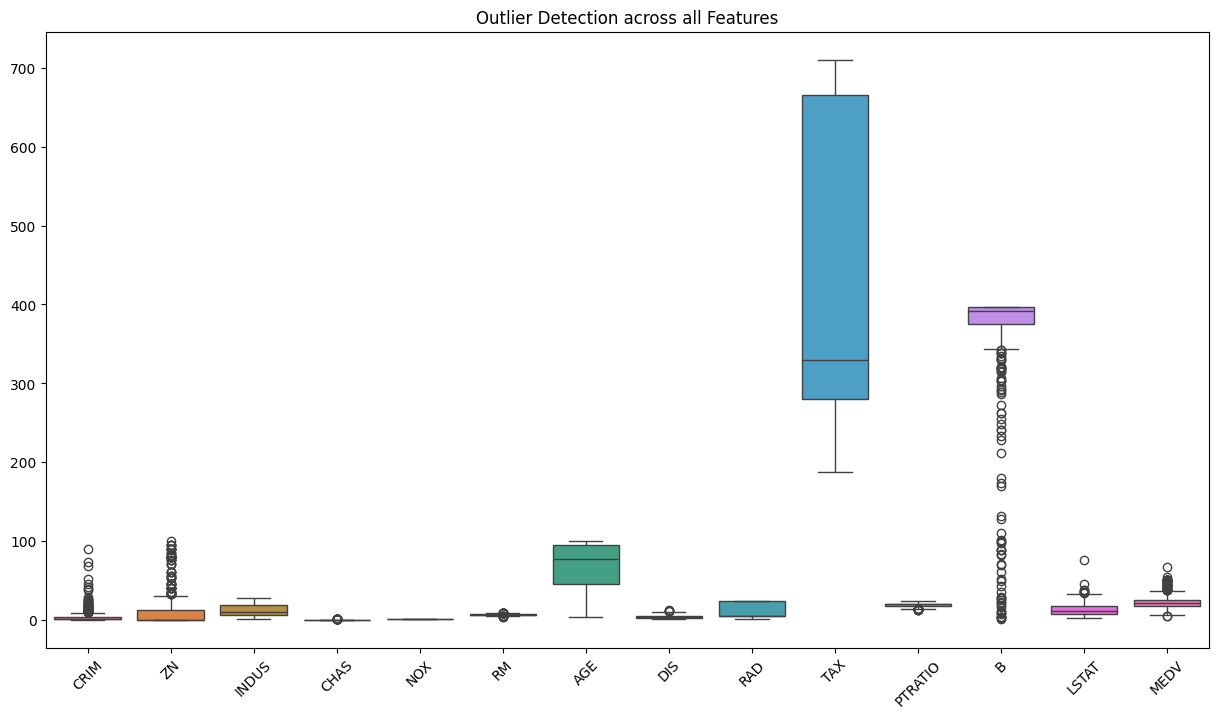

In [10]:
# 2. Outlier Detection (Boxplots)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Outlier Detection across all Features")


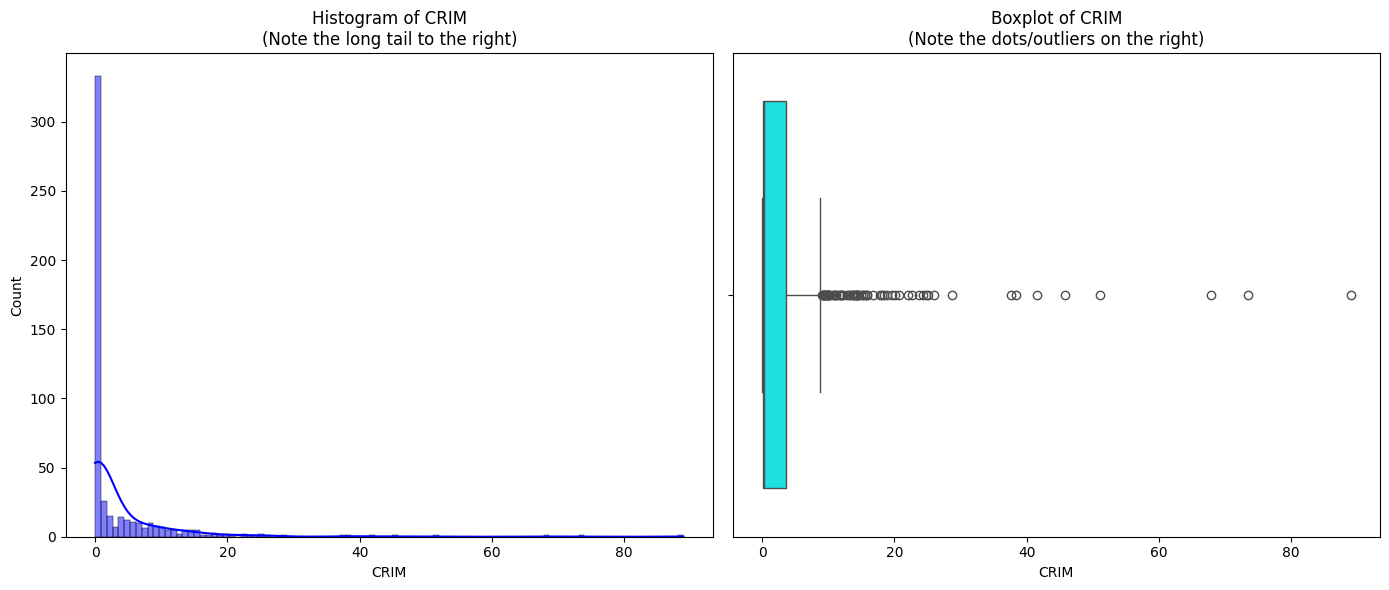

In [16]:


# Let's use CRIM as an example (highly right-skewed)
feature = 'CRIM'

plt.figure(figsize=(14, 6))

# Subplot 1: Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df[feature], kde=True, color='blue')
plt.title(f'Histogram of {feature}\n(Note the long tail to the right)')
plt.xlabel(feature)

# Subplot 2: Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df[feature], color='cyan')
plt.title(f'Boxplot of {feature}\n(Note the dots/outliers on the right)')

plt.tight_layout()


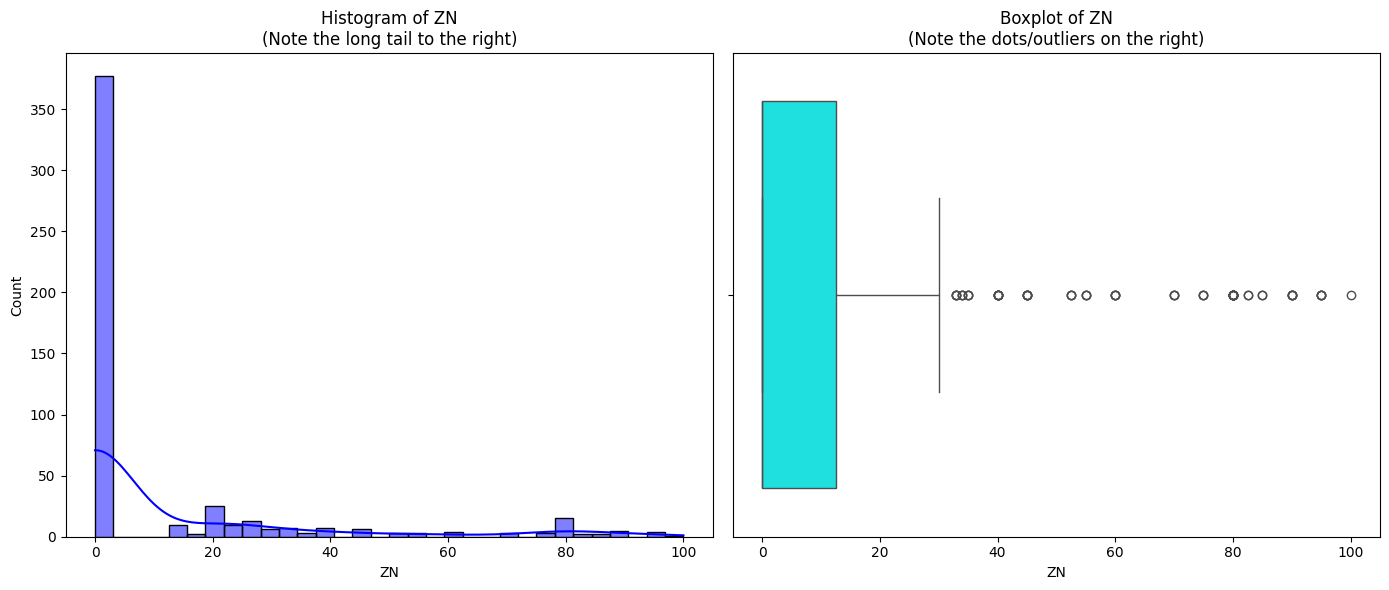

In [ ]:


feature = 'ZN'

plt.figure(figsize=(14, 6))

# Subplot 1: Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df[feature], kde=True, color='blue')
plt.title(f'Histogram of {feature}\n(Note the long tail to the right)')
plt.xlabel(feature)

# Subplot 2: Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df[feature], color='cyan')
plt.title(f'Boxplot of {feature}\n(Note the dots/outliers on the right)')

plt.tight_layout()


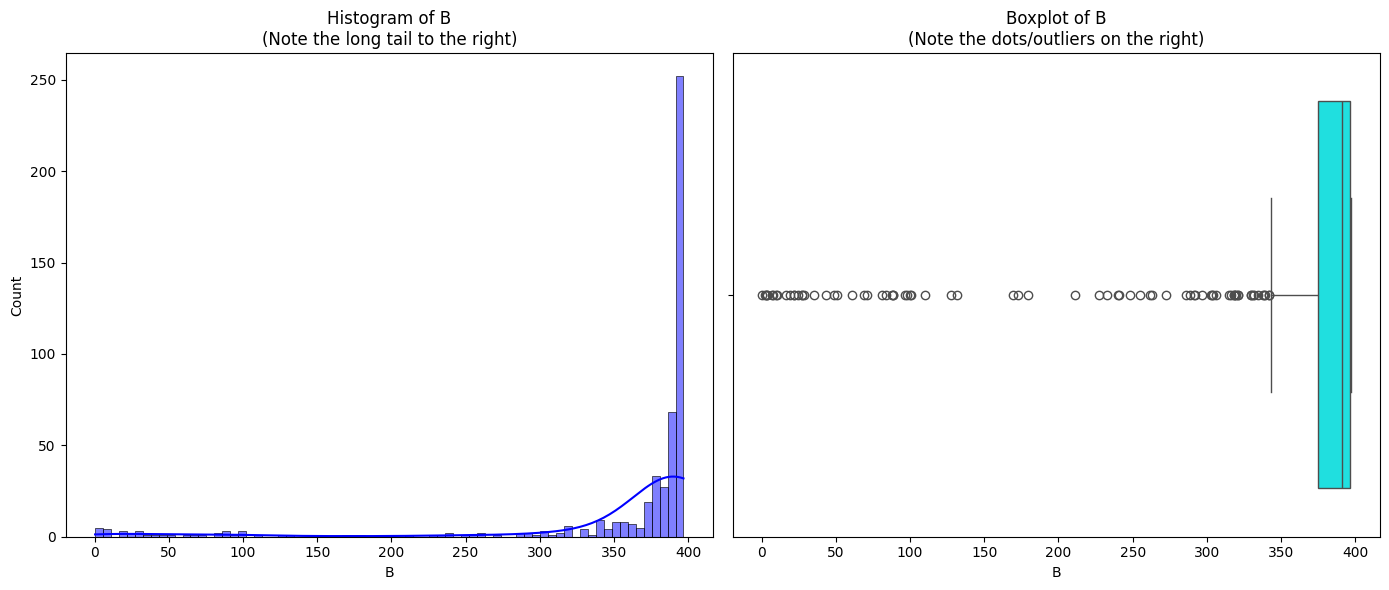

In [ ]:


feature = 'B'

plt.figure(figsize=(14, 6))

# Subplot 1: Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df[feature], kde=True, color='blue')
plt.title(f'Histogram of {feature}\n(Note the long tail to the left)')
plt.xlabel(feature)

# Subplot 2: Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df[feature], color='cyan')
plt.title(f'Boxplot of {feature}\n(Note the dots/outliers on the left)')

plt.tight_layout()


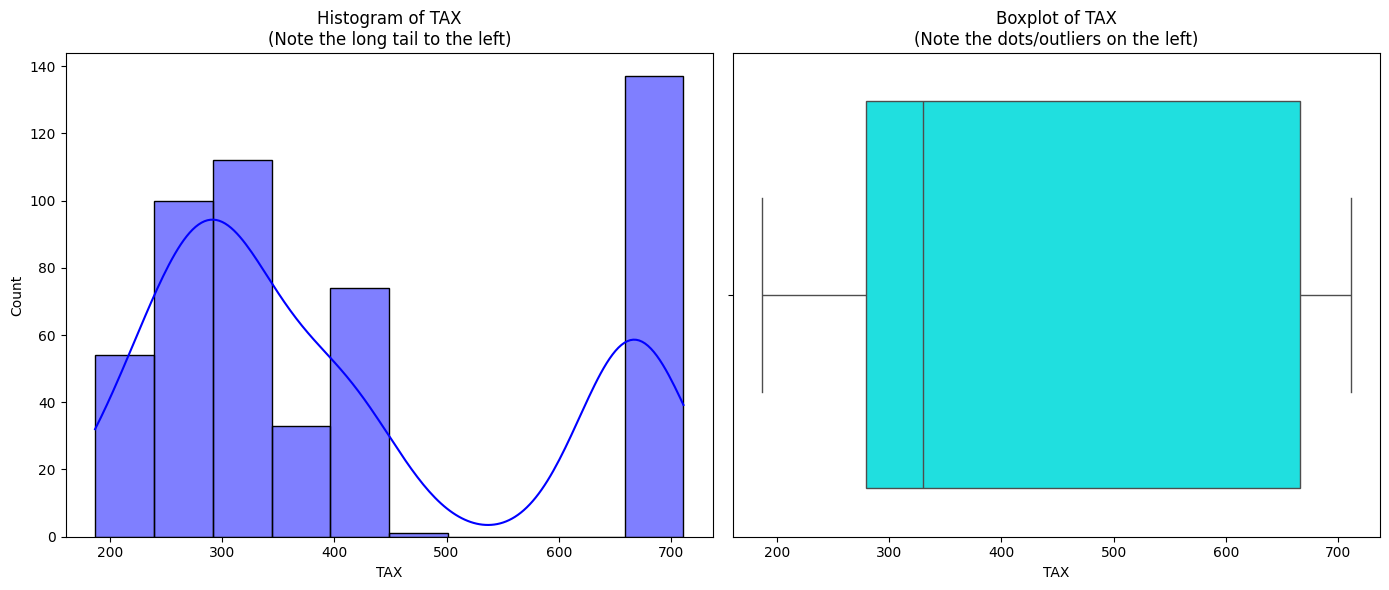

In [19]:


feature = 'TAX'

plt.figure(figsize=(14, 6))

# Subplot 1: Histogram + KDE
plt.subplot(1, 2, 1)
sns.histplot(df[feature], kde=True, color='blue')
plt.title(f'Histogram of {feature}\n(Note the long tail to the left)')
plt.xlabel(feature)

# Subplot 2: Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df[feature], color='cyan')
plt.title(f'Boxplot of {feature}\n(Note the dots/outliers on the left)')

plt.tight_layout()


We can observe the skewness in the data as see in the picture for Skewness Indicator: If the median line is not in the middle of the box, the data is skewed.These outliers create the skewness because they "pull" the mean away from the median.

CRIM (Crime rate) and B have huge outliers. This means some neighborhoods are extreme outliers in these areas.



Analysis of the Histograms and Boxplots for 'CRIM','B' revealed a heavy right-skew (5.25),(3.43), driven by extreme outliers. To ensure my Linear Regression model isn't biased by these high-crime anomalies, I will apply a Log Transformation to normalize the distribution.

Text(0.5, 1.0, 'Correlation Matrix')

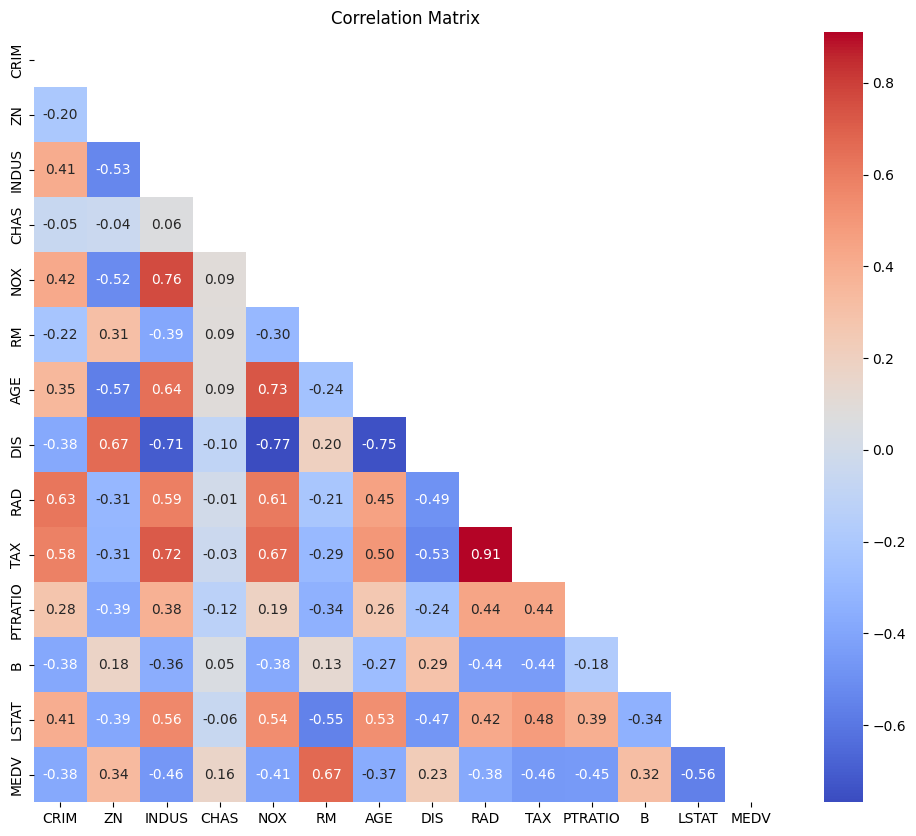

In [11]:
# 3. Correlation Matrix (The 'Logic' check)
# Shows which features drive the price
plt.figure(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # Cleaner view
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")


1) RM (Rooms) has a +0.67 correlation with price. More rooms = Higher price 


Conducted EDA revealing 5 missing values in RM and significant right-skewness in Crime data. Correlation analysis identified RM and LSTAT as the primary features for price prediction.

Text(0.5, 1.0, 'Price Distribution (Target Variable)')

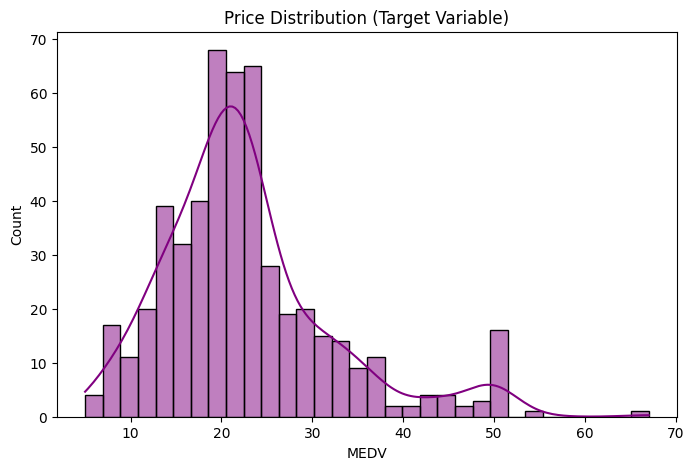

In [12]:
# 4. Target Variable Analysis (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['MEDV'], kde=True, color='purple')
plt.title("Price Distribution (Target Variable)")


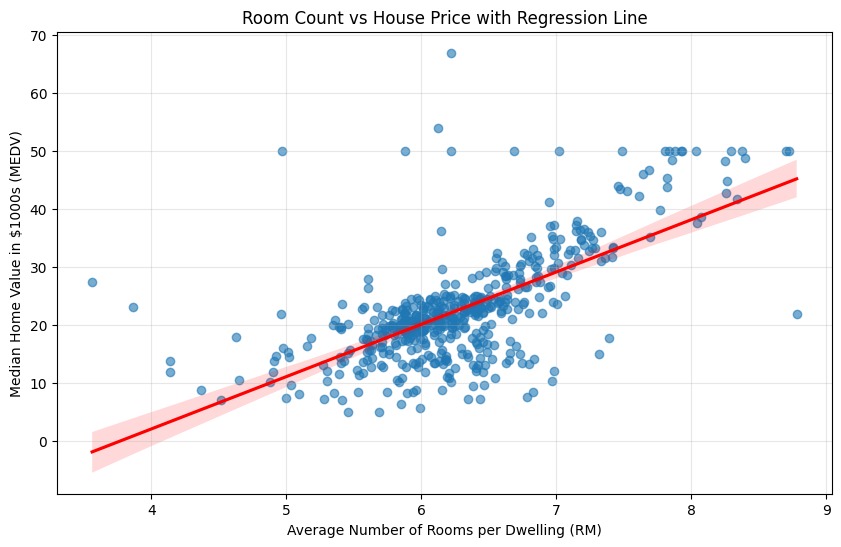

In [13]:
# Scatter plot: RM (Rooms) vs MEDV (Price) with regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='RM', y='MEDV', data=df, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.xlabel('Average Number of Rooms per Dwelling (RM)')
plt.ylabel('Median Home Value in $1000s (MEDV)')
plt.title('Room Count vs House Price with Regression Line')
plt.grid(True, alpha=0.3)
plt.show()

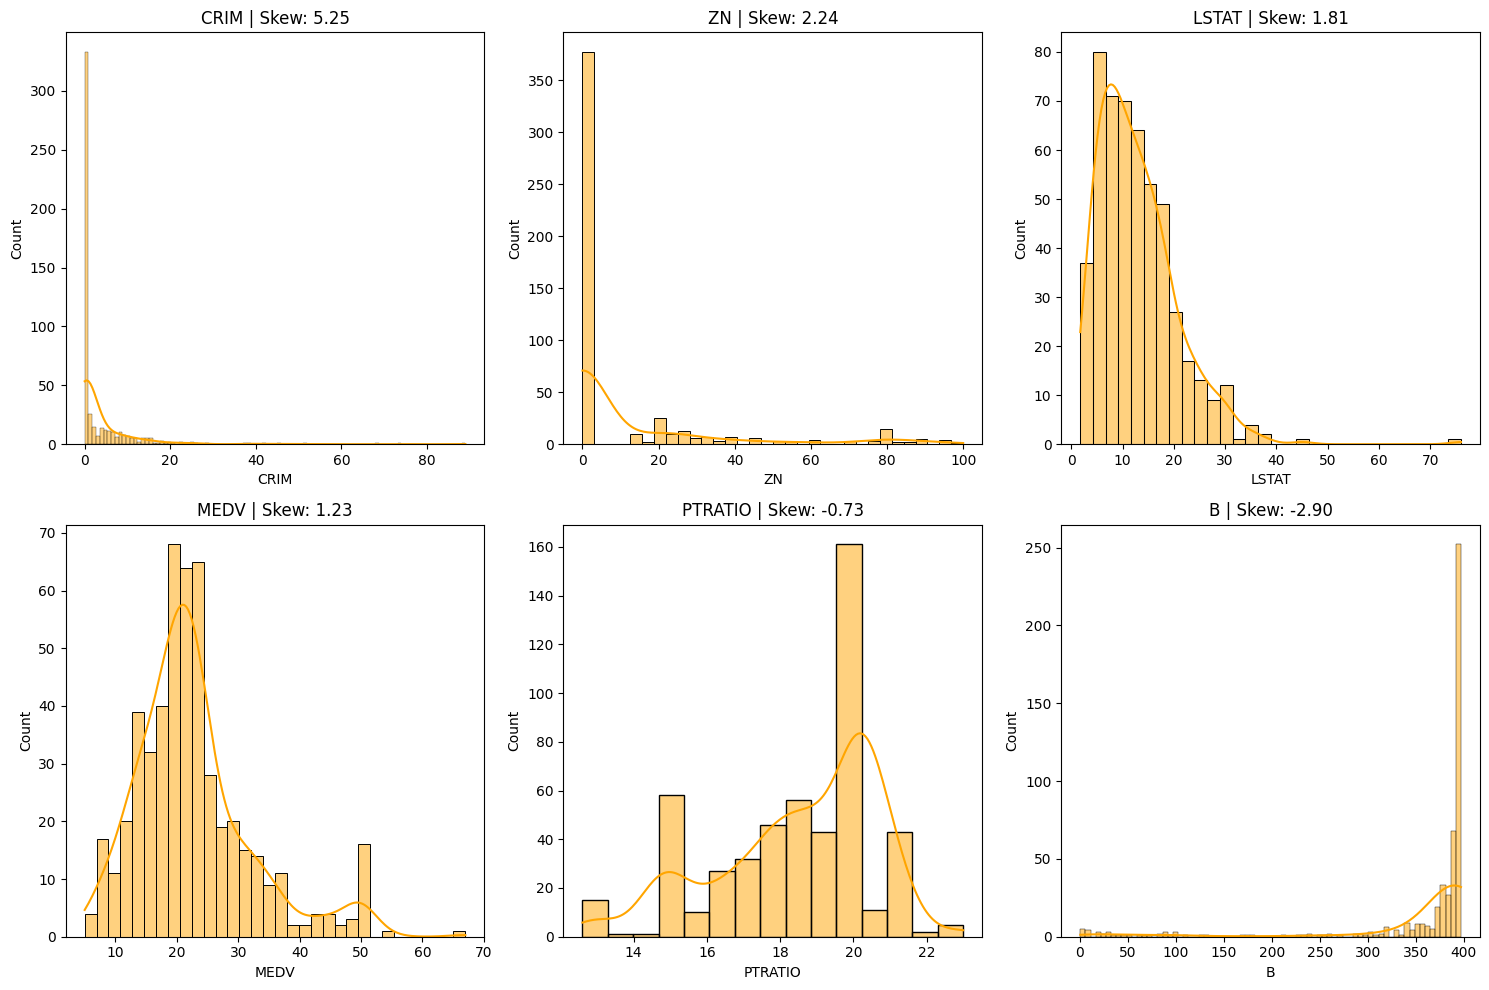

In [ ]:

# Calculate skewness
skew_series = df.skew().sort_values(ascending=False)

cols_to_plot = ['CRIM', 'ZN', 'LSTAT', 'MEDV', 'PTRATIO', 'B']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, color='orange')
    plt.title(f"{col} | Skew: {df[col].skew():.2f}")

plt.tight_layout()


Right Skewed (Positive): The "tail" is on the right side. Most data points are small, but a few very large values pull the average up. (e.g., CRIM or ZN).

Left Skewed (Negative): The "tail" is on the left side. Most data points are large, but a few small values pull the average down. (e.g., B or PTRATIO).

Normal Distribution: Symmetrical, like a bell curve. we need to fix this skewness otherwise it will impact our model perfomance. 

# Let's check skewnewss now as we fixed it by log transformation

New Skewness values after Log Transformation:
CRIM: 1.28
ZN: 1.21
LSTAT: -0.11
MEDV: -0.19
B: -4.48


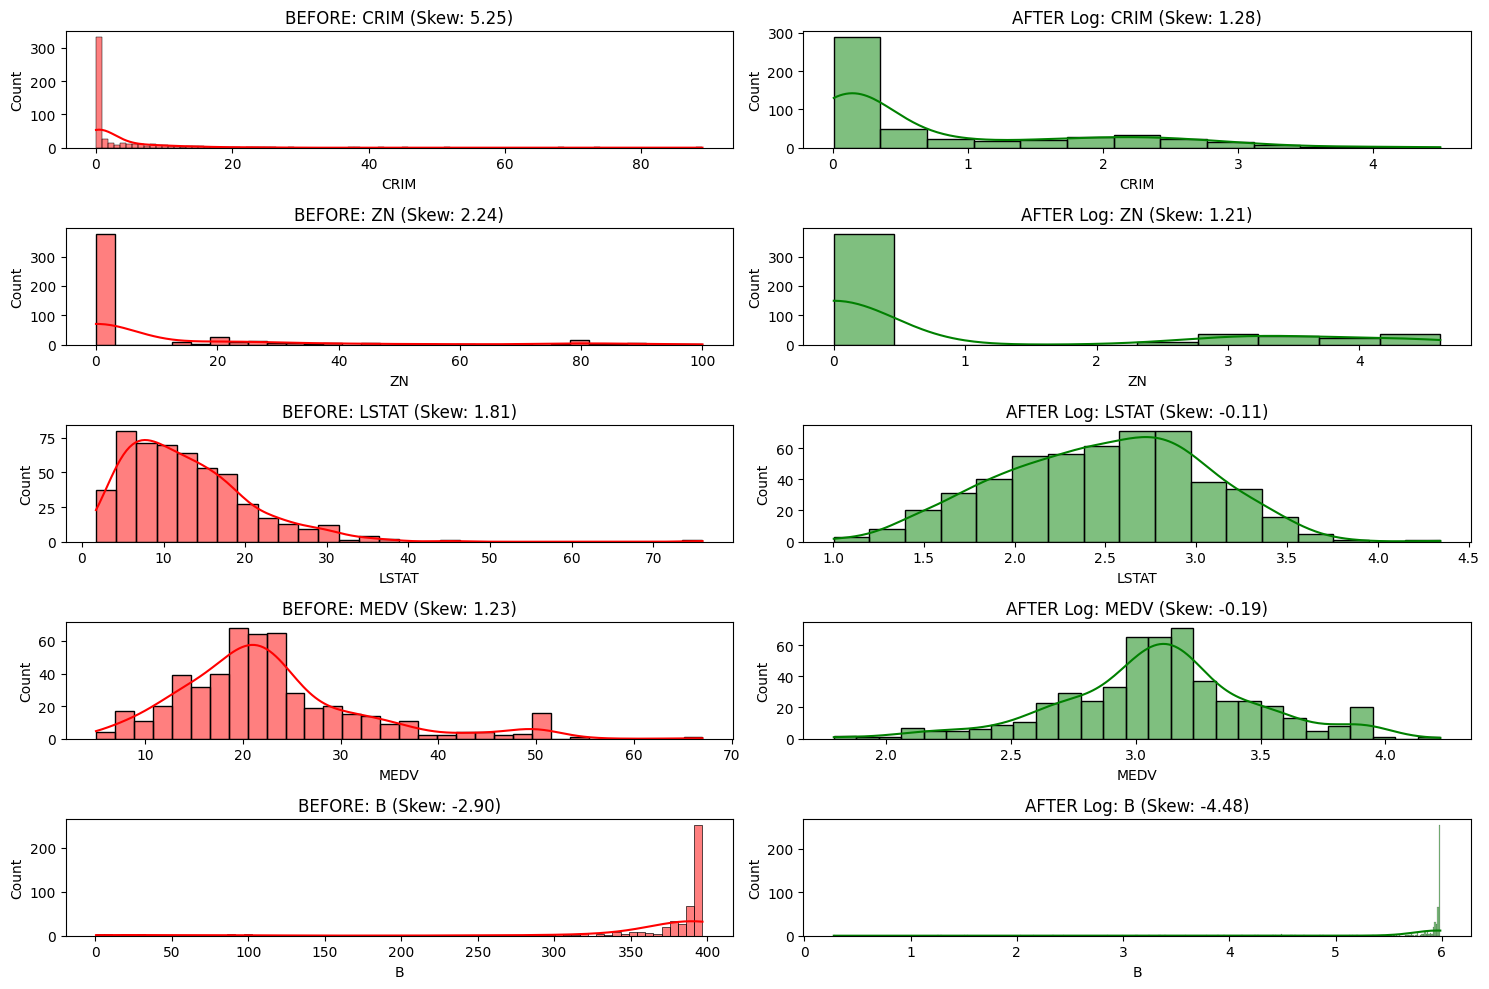

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('../data/data.csv')

# List of highly right-skewed columns to transform
skewed_cols = ['CRIM', 'ZN', 'LSTAT', 'MEDV', 'B']

# Create a figure to compare Before vs After
plt.figure(figsize=(15, 10))

for i, col in enumerate(skewed_cols):
    # Before
    plt.subplot(len(skewed_cols), 2, 2*i + 1)
    sns.histplot(df[col], kde=True, color='red')
    plt.title(f'BEFORE: {col} (Skew: {df[col].skew():.2f})')
    
    # After (Log Transformation)
    # Using log1p (log(1+x)) to handle zeros in CRIM and ZN
    transformed_data = np.log1p(df[col])
    plt.subplot(len(skewed_cols), 2, 2*i + 2)
    sns.histplot(transformed_data, kde=True, color='green')
    plt.title(f'AFTER Log: {col} (Skew: {transformed_data.skew():.2f})')

plt.tight_layout()
plt.savefig('skewness_fixed_comparison.png')

# Print the new skewness values
print("New Skewness values after Log Transformation:")
for col in skewed_cols:
    print(f"{col}: {np.log1p(df[col]).skew():.2f}")

## (A skewness between -0.5 and 0.5 is considered nearly symmetrical/perfect for most models.)

Here still we are facing problem in B, ZN, CRIME! xd. Now let's apply Quantile Transformation.

c:\Users\saqib\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_data.py:2663: UserWarning: n_quantiles (1000) is greater than the total number of samples (511). n_quantiles is set to n_samples.
  warnings.warn(


Skewness Comparison:
CRIM: Original=5.25 -> Quantile=0.00
ZN: Original=2.24 -> Quantile=1.13
B: Original=-2.90 -> Quantile=0.96


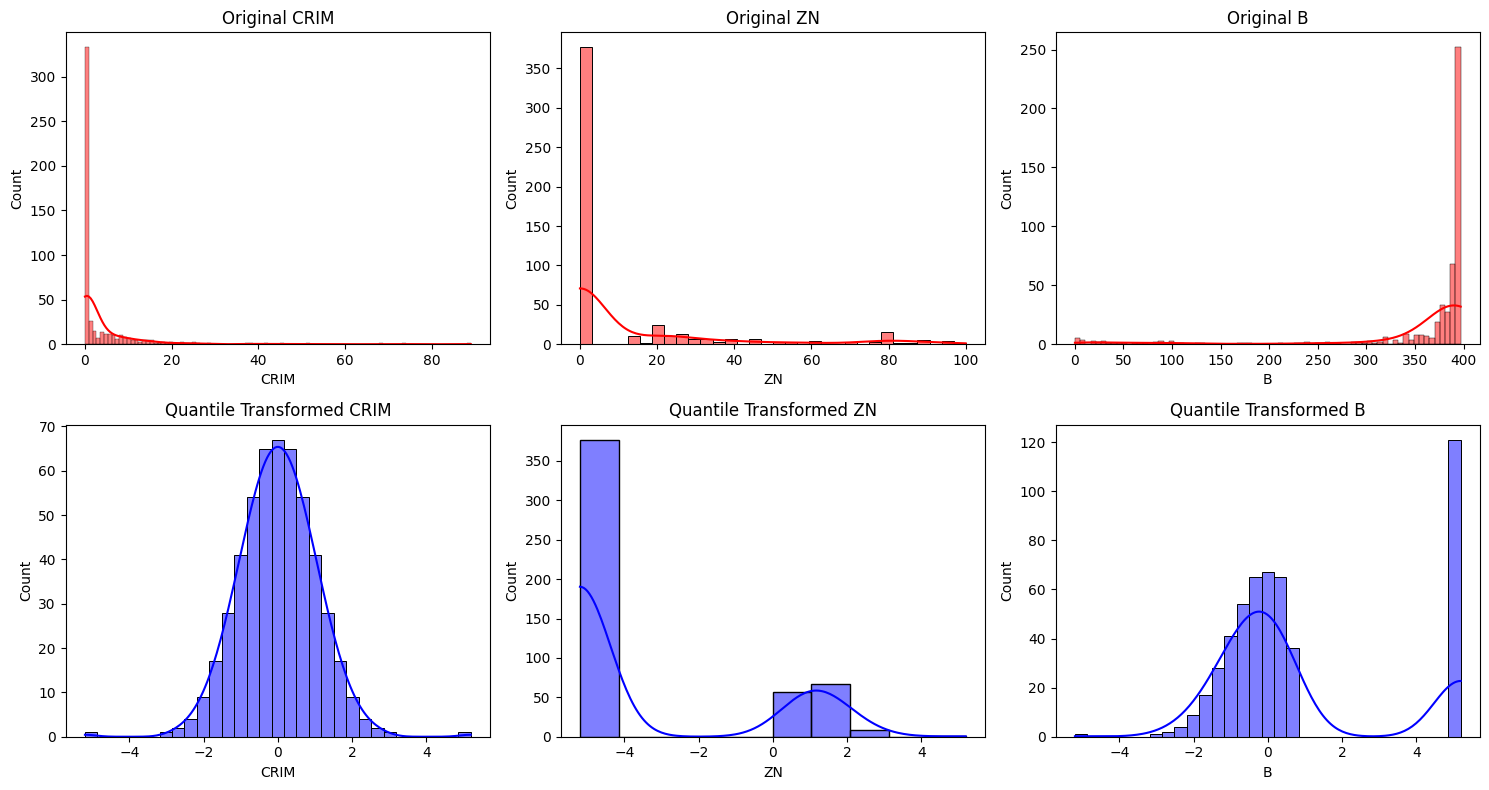

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import QuantileTransformer
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/data.csv')

# Handle missing values first so transformer doesn't fail
df['RM'] = df['RM'].fillna(df['RM'].median())

# Columns the user is worried about
problem_cols = ['CRIM', 'ZN', 'B']

# Apply Quantile Transformation (Industry 'Heavy Duty' Fix)
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_transformed = df.copy()
df_transformed[problem_cols] = qt.fit_transform(df[problem_cols])

# Compare Skewness
print("Skewness Comparison:")
for col in problem_cols:
    original = df[col].skew()
    new = df_transformed[col].skew()
    print(f"{col}: Original={original:.2f} -> Quantile={new:.2f}")

# Visualization
plt.figure(figsize=(15, 8))
for i, col in enumerate(problem_cols):
    # Original
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, color='red')
    plt.title(f"Original {col}")
    
    # Transformed
    plt.subplot(2, 3, i+4)
    sns.histplot(df_transformed[col], kde=True, color='blue')
    plt.title(f"Quantile Transformed {col}")

plt.tight_layout()


we can now see mostly now, it's bell shaped but still there is some problem with zn. leave that for now. 


c:\Users\saqib\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_data.py:2663: UserWarning: n_quantiles (1000) is greater than the total number of samples (511). n_quantiles is set to n_samples.
  warnings.warn(


CRIM: Original=5.25 | New=0.00
ZN: Original=2.24 | New=1.13
B: Original=-2.90 | New=0.96

--- Correlation with Target (MEDV) ---
CRIM: Original Corr=-0.3801 | New Corr=-0.4327
ZN: Original Corr=0.3398 | New Corr=0.3582
B: Original Corr=0.3179 | New Corr=-0.0170


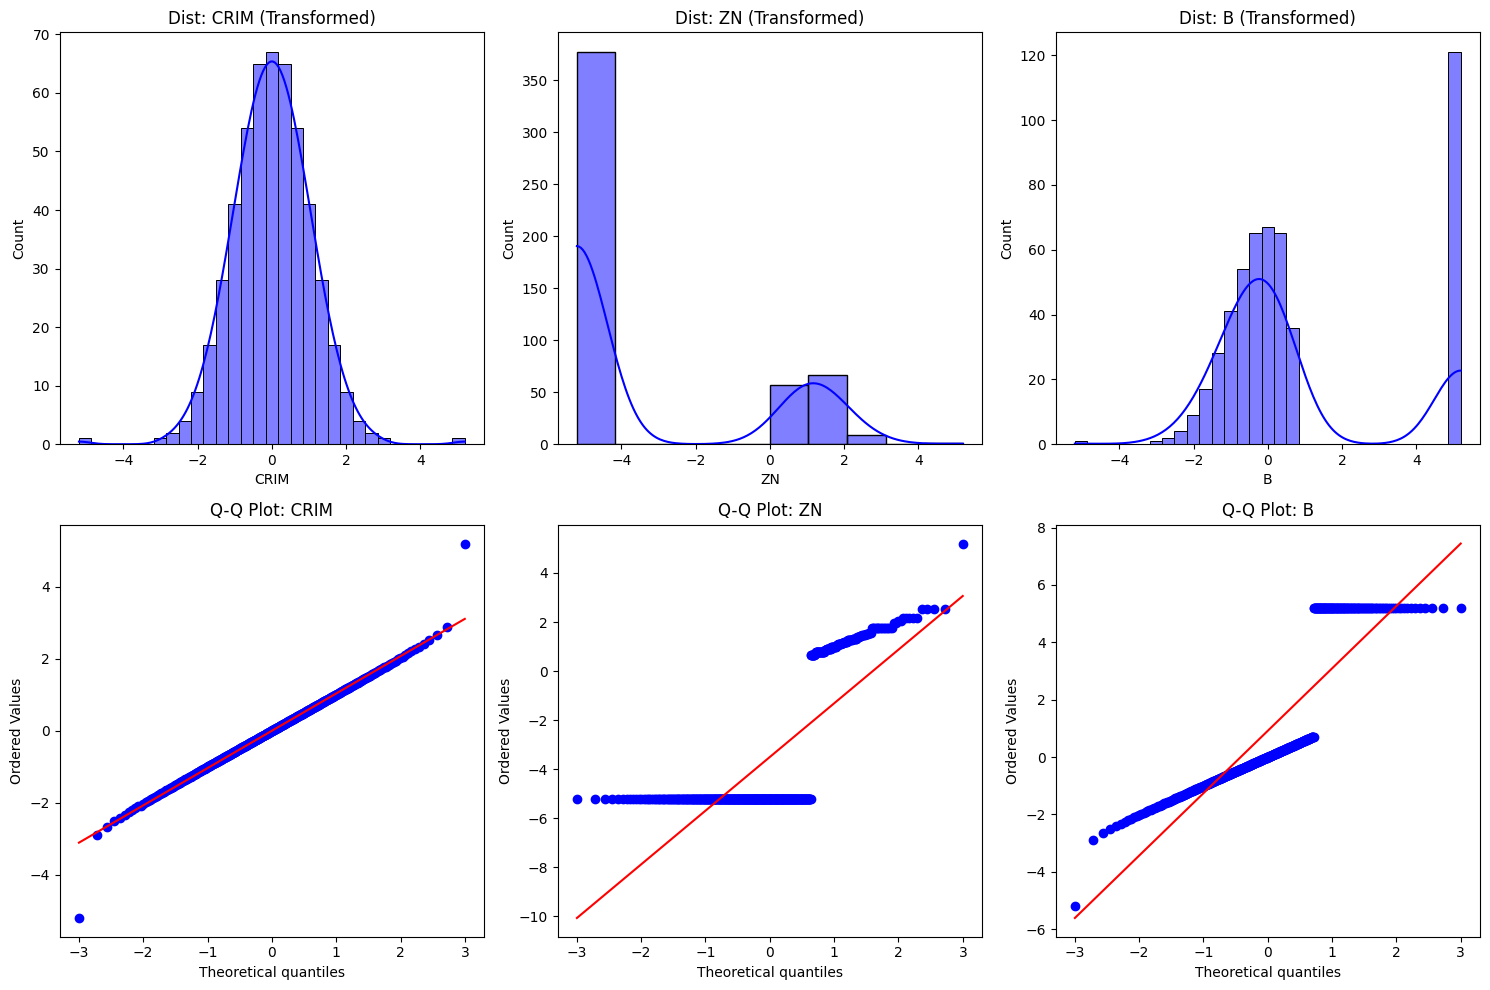

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer

# Load data
df = pd.read_csv('../data/data.csv')
df['RM'] = df['RM'].fillna(df['RM'].median()) # Simple fix for RM

problem_cols = ['CRIM', 'ZN', 'B']
target = 'MEDV'

# Apply Quantile Transformation
qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_transformed = df.copy()
df_transformed[problem_cols] = qt.fit_transform(df[problem_cols])

# 1. Check Skewness
for col in problem_cols:
    s_orig = df[col].skew()
    s_new = df_transformed[col].skew()
    print(f"{col}: Original={s_orig:.2f} | New={s_new:.2f}")

# 2. Check Correlation with Target (Information Preservation)
print("\n--- Correlation with Target (MEDV) ---")
for col in problem_cols:
    c_orig = df[[col, target]].corr().iloc[0, 1]
    c_new = df_transformed[[col, target]].corr().iloc[0, 1]
    print(f"{col}: Original Corr={c_orig:.4f} | New Corr={c_new:.4f}")

# 3. Visualization: Probability Plot (Q-Q Plot)
# A Q-Q plot to check for Normality.
# If the dots follow the red line, the transformation is "OK".
import scipy.stats as stats

plt.figure(figsize=(15, 10))
for i, col in enumerate(problem_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_transformed[col], kde=True, color='blue')
    plt.title(f"Dist: {col} (Transformed)")
    
    plt.subplot(2, 3, i+4)
    stats.probplot(df_transformed[col], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {col}")

plt.tight_layout()
plt.savefig('../data/quantile_validation.png')

If the blue dots lie on the diagonal red line, the transformation is successful.

As you can see in the generated validation plots, the dots for CRIM now follow that red line almost perfectly. This is the visual "proof" that the model will now see the data as a Bell Curve.